# Семинар 7. Практика с Hugging Face 🤗 и Fine-tuning BERT под конкретную задачу

**Тема:** дообучение трансформерной модели семейства BERT для **классификации текста** с помощью `transformers` + `datasets` + `Trainer`.

#### Наш план на сегодня

1. Быстро применим готовые модели через `pipeline`.
2. Подготовим датасет (Kaggle *Women’s E-Commerce Clothing Reviews* или fallback на HF датасет).
3. Соберём даталоадинг на базе `datasets.Dataset` и токенизатора.
4. Дообучим BERT под бинарную классификацию (**Recommended IND**).
5. Сравним несколько вариантов BERT-класса: **BERT / RoBERTa / DistilBERT**.
6. Залезем в тело BERT: посмотрим **hidden states**, **attentions** и визуализируем attention через **BERTviz**.

> Важно: для трансформеров *часто не нужна агрессивная очистка текста* (удалять пунктуацию/стоп-слова и т.п.). Мы это покажем как вариант, но обсудим, почему иногда это ухудшает качество.


## Теоретическая вставка

### Что такое Hugging Face и из чего он состоит

Hugging Face - это экосистема инструментов вокруг моделей и датасетов:

* **[Hub](https://huggingface.co/docs/hub/index)** - маркетплейс моделей/датасетов/демо (веса, model cards, лицензии, версии).
* **[`transformers`](https://huggingface.co/docs/transformers/index)** - модели + токенизаторы + утилиты обучения (pipelines, Trainer, generation).
* **[`tokenizers`](https://huggingface.co/docs/tokenizers/index)** - библиотека для быстрых токенизаторов и обучения своих токенизаторов (обычно под капотом transformers).
* **[`datasets`](https://huggingface.co/docs/datasets/index)** - загрузка/обработка датасетов (map/shuffle/split/cache, стриминг и т.п.).
* **[`evaluate`](https://huggingface.co/docs/evaluate/index)** - метрики (accuracy, f1, rouge, bleu и др.).
* **[`accelerate`](https://huggingface.co/docs/accelerate/index)** - ускорение обучения/инференса (multi-GPU, mixed precision и т.п.).
* **[`peft`](https://huggingface.co/docs/peft/index)** - Parameter-Efficient Fine-Tuning (LoRA, adapter), когда не хочется/нельзя дообучать все веса.
* **[`bitsandbytes`](https://huggingface.co/docs/bitsandbytes/index)** - квантизация и экономия памяти (чаще для больших моделей, но полезно знать).

Все эти библиотеки согласованы по интерфейсу и хорошо стыкуются друг с другом.

### Как применять модель?

1. **Pipeline** (самый высокий уровень)
   Дай текст → получи ответ. Внутри уже есть:

   * токенизация,
   * модель нужного типа,
   * постобработка (например, label/score).
     Отлично для демо и прототипа.

2. **Tokenizer + Model** (низкий уровень)
   Нужно, когда:

   * вы хотите кастомный train loop,
   * хотите залезть в hidden states / attentions,
   * делаете необычную архитектуру (например, BERT + своя голова),
   * пишете исследование / интерпретацию.

3. **Trainer** (высокий уровень, но для обучения)
   Компромисс: почти всё делает за вас, но вы ещё контролируете:

   * данные, токенизацию, коллатор,
   * гиперпараметры,
   * метрики, логи, сохранение.

**Что хотим получить**

* Text classification: один логит-вектор на весь текст (`[CLS]`-представление + классификационная голова).
* Token classification (NER): логит-вектор на каждый токен.
* Masked LM: предсказание замаскированных токенов.
* Seq2seq: генерация (T5/BART и т.д.) - это уже другой класс задач.

### BERT - cемейство решений

Важно разделять:

* **Backbone** (энкодер): BERT/RoBERTa/DistilBERT - генератор представлений.
* **Task head** (голова): маленький слой(слои), который превращает представления в предсказания для конкретной задачи.

В `transformers` это оформлено классами:

* `AutoModel` - только backbone (для эмбеддингов/фичей).
* `AutoModelForSequenceClassification` - backbone + голова для классификации текста.
* `AutoModelForTokenClassification` - backbone + голова для токен-классификации.
* `AutoModelForMaskedLM` - backbone + голова для MLM.

> Почему без fine-tuning не полетит: голова для вашей задачи либо отсутствует, либо случайно инициализирована, либо не соответствует числу классов.

### Tokenizer

Токенизатор - это:

* разбиение на токены (часто subword, например WordPiece/BPE),
* добавление *special tokens* (`[CLS]`, `[SEP]`, `[PAD]`, `[MASK]`),
* преобразование в `input_ids`,
* создание `attention_mask` (где реальные токены, а где паддинг).

Ключевые моменты для практики:

* Truncation: если текст длиннее `max_length`, лишнее отрежется.
* Padding:

  * фиксированный (`padding="max_length"`) - проще, но тратит память,
  * динамический через `DataCollatorWithPadding` - обычно быстрее и экономнее.
* Для пар предложений (например, NLI) появляются `token_type_ids` (у BERT), но не у всех моделей.

### Datasets

`datasets.Dataset` удобен тем, что:

* быстрый `map()` (можно параллелить `num_proc`),
* кэширование преобразований,
* стандартная структура для `Trainer`,
* можно прозрачно работать с большими датасетами.

Типичный конвейер:

1. загрузили/подготовили колонки: `text`, `label`,
2. сделали `train_test_split`,
3. `map(tokenize_fn, batched=True)`,
4. включили `DataCollatorWithPadding`,
5. отдали в `Trainer`.

### Trainer

`Trainer` автоматизирует рутинный пайплайн:

* batching + collate,
* forward/backward,
* optimizer + scheduler (если нужно),
* eval loop,
* логирование, сохранение, best checkpoints,
* mixed precision (`fp16`) и т.д.

Что мы задаём:

* `TrainingArguments` (эпохи, batch size, lr, weight decay, стратегии eval/save),
* датасеты,
* токенизатор/коллатор,
* `compute_metrics`.

> Почему это хорошо для обучения?
>
>* меньше шансов ошибиться в технической обвязке,
>* проще сравнивать эксперименты,
>* легче воспроизводить результаты.

## Fine-tuning vs Feature extraction vs PEFT

Три популярных режима адаптации модели:

1. **Feature extraction**
   Заморозили backbone, берём эмбеддинги (`[CLS]` или mean pooling), сверху обучаем простую модель.

   * быстро, мало ресурсов - обычно хуже, чем полный fine-tuning на сложных задачах

2. **Full fine-tuning**
   Обучаем все веса backbone + голову.

   * обычно лучший quality/ceiling - дороже, больше риск overfitting на маленьком датасете

3. **PEFT (LoRA/adapters)**
   Не трогаем большинство весов, обучаем небольшие добавки.

   * сильно экономит память/время
   * удобно, если много задач/доменных адаптаций - чуть сложнее сетап (но в HF это уже стандарт)

### Практические грабли

* Агрессивная очистка текста (стоп-слова/пунктуация) часто ухудшает качество для трансформеров.
* Слишком маленький `max_length` - вы теряете хвост текста и качество.
* Несоответствие названия лейбла: в HF обычно ожидается колонка `labels`.
* Дисбаланс классов - accuracy врёт, надо F1/PR.
* Слишком большой LR - модель разваливается, типичные стартовые:
  * `1e-5`, `2e-5`, `5e-5` для BERT-base.
* Для быстрых экспериментов:
  * меньше эпох,
  * меньше данных (subset),
  * DistilBERT как быстрый baseline.

### Setting

In [14]:
!pip -q install "transformers[torch]" datasets evaluate accelerate bertviz scikit-learn nltk

In [15]:
import os
import re
import string
import math
import inspect
import random
import numpy as np
import pandas as pd

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

torch: 2.9.0+cu126
cuda available: True


device(type='cuda')

### Вспомним верхний уровень: pipelines

`pipeline` - самый быстрый способ применить готовую модель:
- внутри уже есть токенизация,
- правильный тип модели для задачи,
- постобработка ответа.

Это удобно для прототипов и демо, но если нужно реально хорошее качество на вашей задаче - модель почти всегда стоит дообучать.


In [16]:
import transformers

classifier = transformers.pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)

Device set to use cuda:0


In [17]:
print(classifier("This finally makes sense - I'm genuinely impressed."))

[{'label': 'POSITIVE', 'score': 0.9998682737350464}]


In [18]:
print(classifier("The whole thing was a frustrating mess and I'm disappointed."))

[{'label': 'NEGATIVE', 'score': 0.9997771382331848}]


In [19]:
print(classifier("Well… it wasn’t bad, I guess."))

[{'label': 'POSITIVE', 'score': 0.9903259873390198}]


### Мини-пример

Сделаем словарь `outputs` из мини-датасета: 1 если позитив, 0 если негатив.


In [20]:
import base64

data = {
    "gryffindor": "You're a wizard, Harry.",
    "hufflepuff": "Mischief managed.",
    "ravenclaw": "After all this time? Always.",
    "slytherin": "Dementors are dreadful - they make me feel utterly miserable."
}

outputs = {k: 1 if classifier(v)[0]["label"] == "POSITIVE" else 0 for k, v in data.items()}

assert sum(outputs.values()) == 3 and outputs[base64.decodebytes(b'c2x5dGhlcmlu\n').decode()] == 0
outputs

{'gryffindor': 1, 'hufflepuff': 1, 'ravenclaw': 1, 'slytherin': 0}

BERT умеет восстанавливать пропущенное слово по контексту.

In [21]:
import transformers

mlm_model = transformers.pipeline("fill-mask", model="bert-base-uncased")
MASK = mlm_model.tokenizer.mask_token

text = f"This dress is absolutely {MASK}."
for hypo in mlm_model(text, top_k=5):
    print(f"P={hypo['score']:.5f}", hypo['sequence'])

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


P=0.30776 this dress is absolutely stunning.
P=0.13371 this dress is absolutely gorgeous.
P=0.13034 this dress is absolutely beautiful.
P=0.11791 this dress is absolutely perfect.
P=0.06942 this dress is absolutely amazing.


И мини-задачка (как zero-shot-ish трюк): ограничим кандидаты и посмотрим, что модель считает более подходящим:

In [22]:
candidates = ["great", "good", "bad", "terrible"]
mlm_model(f"The review was {MASK}.", targets=candidates)

[{'score': 0.0034693533089011908,
  'token': 2204,
  'token_str': 'good',
  'sequence': 'the review was good.'},
 {'score': 0.00020339373440947384,
  'token': 2307,
  'token_str': 'great',
  'sequence': 'the review was great.'},
 {'score': 9.118178422795609e-05,
  'token': 2919,
  'token_str': 'bad',
  'sequence': 'the review was bad.'},
 {'score': 4.250083657098003e-05,
  'token': 6659,
  'token_str': 'terrible',
  'sequence': 'the review was terrible.'}]

> `fill-mask` предсказывает **один токен** на месте `[MASK]`. Если вы хотите “слово” из нескольких сабтокенов (типа `unbelievable` или что-то редкое) - нужно либо переформулировать фразу, либо делать несколько шагов/масок вручную.

### Данные

Используем `imdb` (бинарная классификация), чтобы ноутбук был запускаем везде.

> Приводим данные к общему формату:
- `text` - входной текст
- `label` - метка класса (0/1)


In [23]:
import pandas as pd
from huggingface_hub import hf_hub_download

csv_path = hf_hub_download(
    repo_id="Censius-AI/ECommerce-Women-Clothing-Reviews",
    filename="Womens Clothing E-Commerce Reviews.csv",
    repo_type="dataset",
)

df = pd.read_csv(csv_path)
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [24]:
# удаляем строки без текста отзыва
df = df.dropna(subset=["Review Text"]).copy()

# убираем технический индекс, если есть
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# собираем универсальные колонки под обучение
USE_TITLE = True  # переключатель: добавлять ли Title к тексту

df["Title"] = df["Title"].fillna("").astype(str)
df["Review Text"] = df["Review Text"].astype(str)

if USE_TITLE:
    df["text"] = (df["Title"].str.strip() + ". " + df["Review Text"].str.strip()).str.replace(r"^\.\s*", "", regex=True)
else:
    df["text"] = df["Review Text"].str.strip()

df["label"] = df["Recommended IND"].astype(int)

df[["text", "label"]].head()

,text,label
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,Some major design flaws. I had such high hopes...,0
3,"My favorite buy!. I love, love, love this jump...",1
4,Flattering shirt. This shirt is very flatterin...,1


### Быстрый sanity-check

In [25]:
print("rows:", len(df))
print("label distribution:", df["label"].value_counts(normalize=True).round(3).to_dict())

rows: 22641
label distribution: {1: 0.819, 0: 0.181}

Example text:
 Absolutely wonderful - silky and sexy and comfortable


In [26]:
print("Example text:\n", df["text"].iloc[0][:500])

Example text:
 Absolutely wonderful - silky and sexy and comfortable


### Предобработка текста

BERT обучался на сырых текстах, поэтому:
- lowercase - ок (для `uncased` моделей это не критично),
- удаление пунктуации / цифр / стоп-слов - может быть вредно.

Мы делаем очистку как переключаемую опцию: можно сравнить качество с очисткой и без.


In [27]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(rf"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # стоп-слова - спорно, но окей
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

USE_CLEANING = True  # < переключатель

df = df.copy()
df["text_clean"] = df["text"].apply(clean_text) if USE_CLEANING else df["text"]
df[["text", "text_clean"]].head(3)

,text,text_clean
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store gla...
2,Some major design flaws. I had such high hopes...,major design flaws high hopes dress really wan...


### Train/Val split

Для бинарной классификации делаем стратифицированный сплит.

In [28]:
train_df, val_df = train_test_split(
    df[["text_clean", "label"]],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("train:", len(train_df), "val:", len(val_df))
print("train label dist:", train_df["label"].value_counts(normalize=True).round(3).to_dict())
print("val label dist:  ", val_df["label"].value_counts(normalize=True).round(3).to_dict())

train: 18112 val: 4529
train label dist: {1: 0.819, 0: 0.181}
val label dist:   {1: 0.819, 0: 0.181}


### Baseline (классика): TF‑IDF + Logistic Regression

Это хороший ориентир: если трансформер после дообучения не лучше, значит:
- ошибка в пайплайне, или
- мало данных/плохая разметка, или
- задача решается простыми методами.


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=40000, ngram_range=(1,2))
X_train = tfidf.fit_transform(train_df["text_clean"])
X_val = tfidf.transform(val_df["text_clean"])

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, train_df["label"])

val_pred = clf.predict(X_val)

print("Baseline accuracy:", accuracy_score(val_df["label"], val_pred))
print("Baseline F1:", f1_score(val_df["label"], val_pred))
print(classification_report(val_df["label"], val_pred, digits=4))

Baseline accuracy: 0.8948995363214838
Baseline F1: 0.9382139148494288
              precision    recall  f1-score   support

           0     0.8221    0.5354    0.6484       820
           1     0.9046    0.9744    0.9382      3709

    accuracy                         0.8949      4529
   macro avg     0.8634    0.7549    0.7933      4529
weighted avg     0.8897    0.8949    0.8858      4529



### Подготовка данных под Hugging Face Trainer

`datasets.Dataset`:

- умеет `map`,
- хранит колонки,
- легко отдаётся в `Trainer`.

> Важно про паддинг. Будем использовать динамический паддинг через `DataCollatorWithPadding`.


In [30]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds   = Dataset.from_pandas(val_df, preserve_index=False)

MODEL_CKPT = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT, use_fast=True)

def tokenize_batch(batch):
    return tokenizer(batch["text_clean"], truncation=True, max_length=256)

train_ds_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=["text_clean"])
val_ds_tok   = val_ds.map(tokenize_batch, batched=True, remove_columns=["text_clean"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_ds_tok, val_ds_tok

Map:   0%|          | 0/18112 [00:00<?, ? examples/s]

Map:   0%|          | 0/4529 [00:00<?, ? examples/s]

(Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 18112
 }),
 Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 4529
 }))

### Fine-tuning BERT для бинарной классификации


`AutoModelForSequenceClassification` = backbone (BERT) + классификационная голова.


In [32]:
def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

set_seed(42)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_CKPT, num_labels=2)

training_args = TrainingArguments(
    output_dir="./bert-recommend",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tok,
    eval_dataset=val_ds_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_binary,
)

trainer.train()
trainer.evaluate()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1466755069.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.210300,0.225487,0.903290,0.941475
2,0.153200,0.253231,0.904836,0.941968


{'eval_loss': 0.2532307207584381,
 'eval_accuracy': 0.9048355045263855,
 'eval_f1': 0.9419684933351286,
 'eval_runtime': 1.5768,
 'eval_samples_per_second': 2872.309,
 'eval_steps_per_second': 45.028,
 'epoch': 2.0}

### Error analysis


- confusion matrix
- несколько уверенных ошибок


In [33]:
pred_out = trainer.predict(val_ds_tok)
val_logits = pred_out.predictions
val_labels = pred_out.label_ids
val_preds = np.argmax(val_logits, axis=-1)

print("Confusion matrix:\n", confusion_matrix(val_labels, val_preds))
print("\nReport:\n", classification_report(val_labels, val_preds, digits=4))

Confusion matrix:
 [[ 600  220]
 [ 211 3498]]

Report:
               precision    recall  f1-score   support

           0     0.7398    0.7317    0.7357       820
           1     0.9408    0.9431    0.9420      3709

    accuracy                         0.9048      4529
   macro avg     0.8403    0.8374    0.8389      4529
weighted avg     0.9044    0.9048    0.9046      4529



In [34]:
probs = torch.softmax(torch.tensor(val_logits), dim=-1).numpy()
conf = probs.max(axis=-1)
wrong_idx = np.where(val_preds != val_labels)[0]
wrong_sorted = wrong_idx[np.argsort(-conf[wrong_idx])]

val_texts = val_df["text_clean"].reset_index(drop=True)

for i in wrong_sorted[:5]:
    print("="*80)
    print("true:", int(val_labels[i]), "pred:", int(val_preds[i]), "confidence:", float(conf[i]))
    print(val_texts.iloc[i][:700])

true: 0 pred: 1 confidence: 0.9987331032752991
beautiful jacket well made bought jacket regular returned store petite lovely live ca perfect evening remember buy warmth light cover makes outfit anything else might want wear looks great black white also looks great beautiful soft pinks season cranberry love
true: 0 pred: 1 confidence: 0.9987257122993469
love top top one retailer faves comfortable love quality design receive many compliments top usually wear xs retailer tops xs little tight arms dressing room attendant suggested ordering petite small lose shape glad fits perfect even ordered sale gray color perfect thick thin
true: 0 pred: 1 confidence: 0.9984391331672668
love realize much would love wore work day got compliments long time outfit comfortable easy flattering bought totally whim glad
true: 0 pred: 1 confidence: 0.9980770349502563
love dress also dress 3 4 sleeve tegan tunic love dress dressed
true: 0 pred: 1 confidence: 0.9976125955581665
love usually wear reviews helpful 

### Сравним модели: BERT vs RoBERTa vs DistilBERT

In [36]:
MODEL_CKPTS = [
    "bert-base-uncased",
    "roberta-base",
    "distilbert-base-uncased",
]

def train_eval_one(ckpt: str, train_df, val_df, seed=42):
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(ckpt, use_fast=True)

    def tok_fn(b):
        return tok(b["text_clean"], truncation=True, max_length=256)

    train_ds = Dataset.from_pandas(train_df, preserve_index=False).map(tok_fn, batched=True, remove_columns=["text_clean"])
    val_ds   = Dataset.from_pandas(val_df, preserve_index=False).map(tok_fn, batched=True, remove_columns=["text_clean"])
    collator = DataCollatorWithPadding(tok)

    m = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=2)

    training_args = TrainingArguments(
        output_dir=f"./tmp-{ckpt.replace('/', '_')}",
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.06,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=200,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    tr = Trainer(
        model=m,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics_binary,
    )
    tr.train()
    return tr.evaluate()

results = []
for ckpt in MODEL_CKPTS:
    print("\n", "#"*20, ckpt, "#"*20)
    met = train_eval_one(ckpt, train_df, val_df)
    results.append({"model": ckpt, **{k: float(v) for k, v in met.items() if k.startswith("eval_")}})

pd.DataFrame(results).sort_values("eval_f1", ascending=False)


 #################### bert-base-uncased ####################


Map:   0%|          | 0/18112 [00:00<?, ? examples/s]

Map:   0%|          | 0/4529 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1771743099.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  tr = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.222100,0.234649,0.902186,0.940192


...

Map:   0%|          | 0/4529 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1771743099.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  tr = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.225600,0.230096,0.908368,0.944243


,model,eval_loss,eval_accuracy,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second
2,distilbert-base-uncased,0.230096,0.908368,0.944243,0.9751,4644.844,72.816
1,roberta-base,0.248087,0.902848,0.940460,1.4119,3207.733,50.287
0,bert-base-uncased,0.234649,0.902186,0.940192,1.5948,2839.891,44.520


## Лезем в тело BERT



### Токенизация и специальные токены


У BERT внутри есть полезные выходы:

* **hidden_states**: представления на каждом слое (и эмбеддинги до слоёв тоже),
* **attentions**: матрицы внимания по головам/слоям.

Визуализация attention (например, через **bertviz**) помогает:

* показать, что модель “смотрит” на разные части предложения,
* обсудить head specialization (часть голов ловит синтаксис, часть - шаблоны),
* сделать мост к теме интерпретируемости (BERTology).

> attention-визуализация - не полное объяснение, но хороший окошко внутрь модели.

### Токенизация и специальные токены

In [37]:
inspect_ckpt = "bert-base-cased"
tok = AutoTokenizer.from_pretrained(inspect_ckpt, use_fast=True)

lines = [
    "Luke, I am your father.",
    "Life is what happens when you're busy making other plans.",
    "I have no idea what pneumonoultramicroscopicsilicovolcanoconiosis is."
]

batch = tok(lines, padding=True, truncation=True, return_tensors="pt")
print(batch.keys())
print("input_ids shape:", batch["input_ids"].shape)

print("\nDetokenized examples:")
for i in range(len(lines)):
    print(tok.decode(batch["input_ids"][i]))

print("\nSpecial tokens map:")
tok.special_tokens_map

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

KeysView({'input_ids': tensor([[  101,  4599,   117,   146,  1821,  1240,  1401,   119,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0],
        [  101,  2583,  1110,  1184,  5940,  1165,  1128,   112,  1231,  5116,
          1543,  1168,  2714,   119,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0],
        [  101,   146,  1138,  1185,  1911,  1184,   185,  1673,  1818, 23038,
          7067,  4515,  1596,  5864, 22258,  5053,  8031, 18105,  1233, 17519,
          7235, 10714,  1548,  1110,   119,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]]), 'attention_mask': tensor([[1, 1, 1

{'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]'}

### Hidden states

In [38]:
bert_body = AutoModel.from_pretrained(inspect_ckpt).to(device)
bert_body.eval()

with torch.no_grad():
    out = bert_body(**{k: v.to(device) for k, v in batch.items()}, output_hidden_states=True, return_dict=True)

hidden_states = out.hidden_states
print("num hidden states:", len(hidden_states))
print("one hidden state shape:", hidden_states[0].shape)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

num hidden states: 13
one hidden state shape: torch.Size([3, 26, 768])


In [47]:
bert_body

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

### Мини-визуализация: как меняется представление токена по слоям

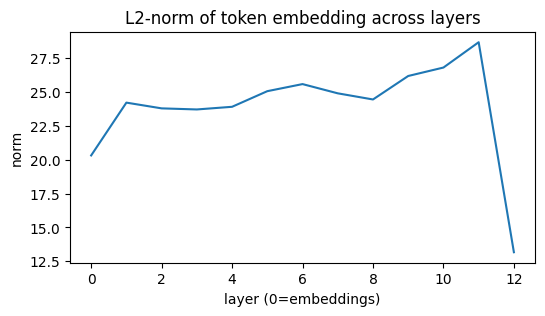

In [39]:
import matplotlib.pyplot as plt

example_idx = 0
token_pos = 1  # 0 обычно [CLS]

vecs = [hs[example_idx, token_pos].detach().cpu().numpy() for hs in hidden_states]
norms = [float(np.linalg.norm(v)) for v in vecs]

plt.figure(figsize=(6, 3))
plt.plot(norms)
plt.title("L2-norm of token embedding across layers")
plt.xlabel("layer (0=embeddings)")
plt.ylabel("norm")
plt.show()

###  Attention + BERTviz

> В Jupyter это откроет интерактивную визуализацию (HTML). Если нужно: `!pip install bertviz`.


In [40]:
!pip -q install bertviz

In [41]:
from bertviz import model_view, head_view

text = "Every time I try to interpret BERT model behaviour, I find new interesting patterns."

viz_model = AutoModel.from_pretrained("bert-base-cased", output_attentions=True).to(device)
viz_tok = AutoTokenizer.from_pretrained("bert-base-cased", use_fast=True)

inputs = viz_tok.encode(text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = viz_model(inputs)

attn = outputs.attentions
tokens = viz_tok.convert_ids_to_tokens(inputs[0].detach().cpu())

print("attentions layers:", len(attn), "one layer shape:", attn[0].shape)
print("tokens:", tokens[:15], "...")

attentions layers: 12 one layer shape: torch.Size([1, 12, 20, 20])
tokens: ['[CLS]', 'Every', 'time', 'I', 'try', 'to', 'interpret', 'B', '##ER', '##T', 'model', 'behaviour', ',', 'I', 'find'] ...


In [44]:
model_view(attn, tokens)

<IPython.core.display.Javascript object>

In [45]:
head_view(attn, tokens)

<IPython.core.display.Javascript object>

### Практика

1) Сравнение очистки текста: `USE_CLEANING=True` vs `False`, сравнить F1.

2) Динамический vs фиксированный паддинг: заменить токенизацию на `padding='max_length'`.

3) Гиперпараметры: `learning_rate ∈ {1e-5, 2e-5, 5e-5}`, `epochs ∈ {1,2,3}`.

4) Заморозка backbone: обучить только голову vs полный fine-tuning.

5) Error analysis: описать 5 типичных ошибок и почему они возникают.


####  Подсказка для freeze backbone

In [43]:
def freeze_backbone(model):
    if hasattr(model, "bert"):
        backbone = model.bert
    elif hasattr(model, "roberta"):
        backbone = model.roberta
    elif hasattr(model, "distilbert"):
        backbone = model.distilbert
    else:
        raise ValueError("Unknown backbone attribute for this model.")

    for p in backbone.parameters():
        p.requires_grad = False
    return model

tmp_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
tmp_model = freeze_backbone(tmp_model)

trainable = sum(p.numel() for p in tmp_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in tmp_model.parameters())
print("trainable params:", trainable, "of", total, f"({trainable/total:.2%})")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1538 of 109483778 (0.00%)
